Polars rewrite of aadt_filling_texas.ipynb.

Same algorithm and output schema as the pandas version, with these changes:
- pandas -> polars (lazy where it helps, eager per-year)
- geopandas sjoin -> polars-st sjoin for ZIP polygon assignment
- master input deduplicated up front (fixes the 2016 doubling)
- per-row Point construction replaced with vectorized geometry creation
- BallTree kept as-is (sklearn, numpy-backed, already optimal for k=1)


In [1]:
import os, time
import numpy as np
import polars as pl
import polars_st as st
from sklearn.neighbors import BallTree
import matplotlib.pyplot as plt

# geopandas + shapely used for the ZIP sjoin step
# (polars-st 0.7.0 has API quirks; geopandas with vectorized shapely.points
#  is fast enough and known to work)
import geopandas as gpd
from shapely import points as shapely_points

print('polars   :', pl.__version__)
print('polars-st:', getattr(st, '__version__', 'unknown'))


polars   : 1.40.1
polars-st: 0.7.0


In [2]:
STATIONS_PATH     = 'old_aadt.csv'
MASTER_CRASH_PATH = 'master_data_2015-2024.csv'
ZIP_GEOJSON_PATH  = 'tx_texas_zip_codes_geo.min.json'
OUT_DIR           = 'outputs/'

CRASH_YEARS = list(range(2015, 2025))

MAX_STATION_MILES  = 1.0
EARTH_RADIUS_MILES = 3958.8

TX_LAT_MIN, TX_LAT_MAX =  25.8,  36.5
TX_LON_MIN, TX_LON_MAX = -106.6, -93.5

TX_VMT_MILLIONS = {
    2015: 258300, 2016: 270700, 2017: 273200, 2018: 282200, 2019: 288400,
    2020: 260000, 2021: 285200, 2022: 291100, 2023: 301500, 2024: 307800,
    2025: 307800,
}

os.makedirs(OUT_DIR, exist_ok=True)


Pre-flight: year distribution in the master file, before and after dedupe.
Confirms the upstream 2016 doubling and shows what dedupe recovers.


In [3]:
check = (
    pl.scan_csv(MASTER_CRASH_PATH, skip_rows=4, ignore_errors=True)
      .select(
          pl.col('Crash_Date')
            .str.to_date('%m/%d/%Y', strict=False)
            .dt.year()
            .alias('year')
      )
      .group_by('year')
      .len()
      .sort('year')
      .collect()
)
print('Year counts in master_data (before dedupe):')
print(check)


Year counts in master_data (before dedupe):
shape: (9, 2)
┌──────┬─────────┐
│ year ┆ len     │
│ ---  ┆ ---     │
│ i32  ┆ u32     │
╞══════╪═════════╡
│ 2016 ┆ 1097926 │
│ 2017 ┆ 537497  │
│ 2018 ┆ 544176  │
│ 2019 ┆ 561412  │
│ 2020 ┆ 472050  │
│ 2021 ┆ 547288  │
│ 2022 ┆ 551766  │
│ 2023 ┆ 420714  │
│ 2024 ┆ 549428  │
└──────┴─────────┘


Load and clean the stations table.
Same recipe as the pandas notebook: coerce types, drop nulls and zeros,
dedupe by station id keeping the latest year.


In [4]:
stations = pl.read_csv(STATIONS_PATH, infer_schema_length=10_000)

LAT_COL   = 'LATITUDE'
LON_COL   = 'LONGITUDE'
LOC_COL   = 'TRFC_STATN_ID'
COUNT_COL = 'LATEST_AADT_QTY'
YEAR_COL  = 'LATEST_AADT_YR'

stations = (
    stations
    .rename({c: c.strip() for c in stations.columns})
    .with_columns([
        pl.col(LAT_COL).cast(pl.Float64, strict=False),
        pl.col(LON_COL).cast(pl.Float64, strict=False),
        pl.col(COUNT_COL).cast(pl.Float64, strict=False),
        pl.col(YEAR_COL).cast(pl.Int64, strict=False),
        pl.col(LOC_COL).cast(pl.Utf8).str.strip_chars(),
    ])
    .filter(
        pl.col(LAT_COL).is_not_null()
        & pl.col(LON_COL).is_not_null()
        & pl.col(COUNT_COL).is_not_null()
        & (pl.col(COUNT_COL) > 0)
    )
    # Keep latest year per station id (no-op for current file shape, future-proof)
    .sort(YEAR_COL)
    .unique(subset=[LOC_COL], keep='last')
    .rename({COUNT_COL: 'Station_Count', YEAR_COL: 'Station_Year'})
)

print(f'Stations kept: {stations.height:,}')
print(f'Unique IDs   : {stations.select(pl.col(LOC_COL).n_unique()).item():,}')


Stations kept: 100,400
Unique IDs   : 100,400


Build the BallTree. sklearn is numpy-based so we have to drop into ndarray here.
The arrays we extract are also used for direct index lookup when assigning
matched station fields back to crashes.


In [5]:
station_coords_rad = np.radians(stations.select([LAT_COL, LON_COL]).to_numpy())
tree = BallTree(station_coords_rad, metric='haversine')

stat_lat_arr = stations[LAT_COL].to_numpy()
stat_lon_arr = stations[LON_COL].to_numpy()
stat_id_arr = stations[LOC_COL].to_numpy()
stat_count_arr = stations['Station_Count'].to_numpy()
stat_year_arr = stations['Station_Year'].to_numpy()

print(f'BallTree built on {len(station_coords_rad):,} stations')


BallTree built on 100,400 stations


Load the master crash file with `pl.scan_csv` (lazy). Three things happen here:

1. Skip the 4-row mightymerge header.
2. Add Crash_Year column parsed from Crash_Date (MM/DD/YYYY).
3. Deduplicate full rows. The master file has 2016 rows duplicated exactly
   (~550k unique IDs appear twice each). This single call fixes that.

`.unique()` over all columns is safe because the duplicates we found were
exact full-row copies with no conflicting versions.


In [6]:
master_lf = (
    pl.scan_csv(MASTER_CRASH_PATH, skip_rows=4, ignore_errors=True, low_memory=True)
        .unique(subset=['Crash_ID'])           # dedupe on crash id(fixes the 2016 doubling). Not full row dedupe since much slower in Polars
        .with_columns(
          pl.col('Crash_Date').str.to_date('%m/%d/%Y', strict=False).dt.year().alias('Crash_Year'),
          pl.col('Latitude').cast(pl.Float64, strict=False),
          pl.col('Longitude').cast(pl.Float64, strict=False),
      ).filter(
          pl.col('Latitude').is_not_null()
          & pl.col('Longitude').is_not_null()
          & pl.col('Latitude').is_between(TX_LAT_MIN, TX_LAT_MAX)
          & pl.col('Longitude').is_between(TX_LON_MIN, TX_LON_MAX)
      )
)

# Materialize once. Per-year loop filters this in-memory rather than re-scanning
# the CSV every iteration (which was making even empty years slow).
master_df = master_lf.collect()
print(f'Master rows after dedupe and lat/long bounds filter: {master_df.height:,}')


Master rows after dedupe and lat/long bounds filter: 4,266,342


Load ZIP polygons via polars-st. Loaded once outside the year loop.

polars-st's `read_file` returns a DataFrame with a `geometry` column.
We narrow to just the ZCTA code + geometry.


In [7]:
# ZIP polygons as a geopandas GeoDataFrame.
# Using geopandas here because polars-st's sjoin produced silently-empty matches
# in this version. Geopandas + vectorized shapely.points is fast enough.
zip_gdf = gpd.read_file(ZIP_GEOJSON_PATH)[['ZCTA5CE10', 'geometry']]
zip_gdf = zip_gdf.set_crs('EPSG:4326', allow_override=True)
print(f'ZIP polygons loaded: {len(zip_gdf):,}')


ZIP polygons loaded: 1,939


Per-year processing.

For each crash year:
1. Filter master_lf to this year (lazy push-down -> reads only what's needed).
2. Drop null coords + apply Texas bounding box.
3. BallTree query (numpy boundary).
4. Far-mask any match >1 mile.
5. Compute year_gap, VMT_Crash, VMT_Station, VMT_Multiplier, Adt_Curnt_Amt.
6. Spatial join to assign ZIP_Code via polars-st.
7. Drop rows missing ZIP.
8. Write `outputs/Cleaned_Data_<year>.csv`.


In [8]:
import gc

# Partition master_df by year ONCE up front. Each year's slice is a separate
# DataFrame in a dict; we pop them as we iterate so memory is freed
# incrementally rather than holding the full master_df + current year + BallTree
# scratch all at once.
print('Partitioning master_df by Crash_Year...')
year_partitions = master_df.partition_by('Crash_Year', as_dict=True)
print(f'  partitions: {len(year_partitions)}')

# Free master_df now that its data is split across the partition dict.
del master_df
gc.collect()


all_outputs = []
timings = []

for crash_year in CRASH_YEARS:
    t_year_start = time.perf_counter()
    print(f'\n== {crash_year} ==')

    # partition_by(as_dict=True) keys differ across polars versions:
    # 1.x keys by tuple, older versions key by scalar. Handle both.
    key_tuple = (crash_year,)
    if key_tuple in year_partitions:
        df = year_partitions.pop(key_tuple)
    elif crash_year in year_partitions:
        df = year_partitions.pop(crash_year)
    else:
        print(f'  no rows for {crash_year}, skipping')
        continue

    # Column casting moved on top before collecting master_df
    # df = df.with_columns([
    #     pl.col('Latitude').cast(pl.Float64, strict=False),
    #     pl.col('Longitude').cast(pl.Float64, strict=False),
    # ])
    print(f'  rows after bounds filter     : {df.height:,}')

    # Drop the source ZIP_Code; the spatial join below will provide the authoritative one.
    if 'ZIP_Code' in df.columns:
        df = df.drop('ZIP_Code')

    # Bounds filter moved on top before collecting master_df
    # 2) Bounds filter
    # df = df.filter(
    #     pl.col('Latitude').is_not_null()
    #     & pl.col('Longitude').is_not_null()
    #     & pl.col('Latitude').is_between(TX_LAT_MIN, TX_LAT_MAX)
    #     & pl.col('Longitude').is_between(TX_LON_MIN, TX_LON_MAX)
    # )
    # print(f'  after bounds filter   : {df.height:,}')

    # 3) BallTree query (drop to numpy briefly)
    crash_coords = df.select(['Latitude', 'Longitude']).to_numpy()
    crash_coords_rad = np.radians(crash_coords)
    distances_rad, indices = tree.query(crash_coords_rad, k=1)
    distances_miles = distances_rad.flatten() * EARTH_RADIUS_MILES
    idx = indices.flatten()
    # Free temporary coord buffers
    del crash_coords, crash_coords_rad, distances_rad, indices

    df = df.with_columns([
        pl.Series('Nearest_Station_LocationId', stat_id_arr[idx]),
        pl.Series('Station_Lat',                stat_lat_arr[idx]),
        pl.Series('Station_Lon',                stat_lon_arr[idx]),
        pl.Series('Station_Count',              stat_count_arr[idx]).cast(pl.Float64),
        pl.Series('Station_Year',               stat_year_arr[idx]).cast(pl.Int64),
        pl.Series('Distance_Miles',             distances_miles),
    ])
    del idx, distances_miles

    # 4) Far-mask: blank station fields when match >1 mile
    far = pl.col('Distance_Miles') > MAX_STATION_MILES
    df = df.with_columns([
        pl.when(far).then(None).otherwise(pl.col('Nearest_Station_LocationId')).alias('Nearest_Station_LocationId'),
        pl.when(far).then(None).otherwise(pl.col('Station_Lat')).alias('Station_Lat'),
        pl.when(far).then(None).otherwise(pl.col('Station_Lon')).alias('Station_Lon'),
        pl.when(far).then(None).otherwise(pl.col('Station_Count')).alias('Station_Count'),
        pl.when(far).then(None).otherwise(pl.col('Station_Year')).alias('Station_Year'),
    ])
    print(f'  >1mi nulled           : {df.select(far.sum()).item():,}')

    # 5) year_gap + VMT + AADT
    df = df.with_columns(
        (pl.col('Crash_Year') - pl.col('Station_Year')).abs().alias('year_gap')
    )

    # VMT lookup via replace_strict (dict map, vectorized)
    df = df.with_columns([
        pl.col('Crash_Year').replace_strict(TX_VMT_MILLIONS, default=None, return_dtype=pl.Float64).alias('VMT_Crash'),
        pl.col('Station_Year').replace_strict(TX_VMT_MILLIONS, default=None, return_dtype=pl.Float64).alias('VMT_Station'),
    ])

    df = df.with_columns(
        (pl.col('VMT_Crash') / pl.col('VMT_Station')).alias('VMT_Multiplier')
    )
    df = df.with_columns([
        (pl.col('Station_Count') * pl.col('VMT_Multiplier')).alias('Adt_Curnt_Amt'),
        pl.lit(crash_year).cast(pl.Int64).alias('Adt_Curnt_Year'),
        pl.when(pl.col('Station_Count').is_not_null() & pl.col('VMT_Multiplier').is_not_null())
          .then(pl.lit('NEAREST_STATION_VMT_NORM'))
          .otherwise(pl.lit('MISSING'))
          .alias('aadt_match_type'),
    ])

    # 6) ZIP spatial join via shapely + geopandas.
    # Polars -> pandas hop, vectorized shapely.points (C-level), gpd.sjoin, back to Polars.
    pdf = df.to_pandas()
    geoms = shapely_points(pdf['Longitude'].to_numpy(), pdf['Latitude'].to_numpy())
    gdf_crash = gpd.GeoDataFrame(pdf, geometry=geoms, crs='EPSG:4326')
    joined = gpd.sjoin(gdf_crash, zip_gdf, how='left', predicate='within')
    joined = joined.drop(columns=['geometry', 'index_right'])
    df = pl.from_pandas(joined)
    del pdf, geoms, gdf_crash, joined

    # 7) Drop rows missing ZIP, rename to ZIP_Code
    before_zip = df.height
    df = df.filter(pl.col('ZCTA5CE10').is_not_null())
    df = df.rename({'ZCTA5CE10': 'ZIP_Code'})
    df = df.with_columns(pl.col('ZIP_Code').cast(pl.Int64, strict=False))
    print(f'  dropped missing ZIP   : {before_zip - df.height:,}')

    # 8) Write
    out_path = os.path.join(OUT_DIR, f'Cleaned_Data_{crash_year}.csv')
    df.write_csv(out_path)
    filled = df.filter(pl.col('Adt_Curnt_Amt').is_not_null()).height
    pct = 100.0 * filled / df.height if df.height else 0.0
    print(f'  filled / total        : {filled:,}/{df.height:,} ({pct:.2f}%)')

    elapsed = time.perf_counter() - t_year_start
    timings.append((crash_year, df.height, elapsed))
    print(f'  elapsed               : {elapsed:.1f}s')

    all_outputs.append(df)

    # Force GC between years to keep peak memory low
    gc.collect()

print(f'\nTotal years processed: {len(all_outputs)}')


Partitioning master_df by Crash_Year...
  partitions: 9

== 2015 ==
  no rows for 2015, skipping

== 2016 ==
  rows after bounds filter     : 498,336
  >1mi nulled           : 12,343
  dropped missing ZIP   : 1,147
  filled / total        : 478,562/497,189 (96.25%)
  elapsed               : 59.5s

== 2017 ==
  rows after bounds filter     : 486,156
  >1mi nulled           : 12,724
  dropped missing ZIP   : 1,331
  filled / total        : 466,324/484,825 (96.18%)
  elapsed               : 49.0s

== 2018 ==
  rows after bounds filter     : 492,452
  >1mi nulled           : 13,636
  dropped missing ZIP   : 1,525
  filled / total        : 471,780/490,927 (96.10%)
  elapsed               : 56.1s

== 2019 ==
  rows after bounds filter     : 506,318
  >1mi nulled           : 12,986
  dropped missing ZIP   : 1,433
  filled / total        : 485,867/504,885 (96.23%)
  elapsed               : 50.6s

== 2020 ==
  rows after bounds filter     : 425,160
  >1mi nulled           : 11,853
  dropped mis

Combined output for downstream summary / viz.


In [9]:
if all_outputs:
    df_all = pl.concat(all_outputs, how='vertical_relaxed')
    print(f'All years combined: {df_all.height:,} rows')
else:
    df_all = pl.DataFrame()
    print('No outputs produced')


All years combined: 4,255,118 rows


Missing-AADT breakdown. Same four buckets as the pandas notebook,
now computed across all years rather than the last year only.


In [10]:
if df_all.height:
    total   = df_all.height
    missing = df_all.filter(pl.col('Adt_Curnt_Amt').is_null()).height

    no_coords = df_all.filter(
        pl.col('Adt_Curnt_Amt').is_null()
        & (pl.col('Latitude').is_null() | pl.col('Longitude').is_null())
    ).height
    no_station = df_all.filter(
        pl.col('Adt_Curnt_Amt').is_null()
        & pl.col('Nearest_Station_LocationId').is_null()
        & pl.col('Latitude').is_not_null()
        & pl.col('Longitude').is_not_null()
    ).height
    no_station_year = df_all.filter(
        pl.col('Adt_Curnt_Amt').is_null()
        & pl.col('Nearest_Station_LocationId').is_not_null()
        & pl.col('Station_Year').is_null()
    ).height
    no_vmt = df_all.filter(
        pl.col('Adt_Curnt_Amt').is_null()
        & pl.col('Nearest_Station_LocationId').is_not_null()
        & pl.col('Station_Year').is_not_null()
        & pl.col('VMT_Multiplier').is_null()
    ).height

    print(f'Total rows  : {total:,}')
    print(f'Missing AADT: {missing:,} ({missing/total*100:.2f}%)')
    print()
    print(f'  no coords             : {no_coords:,}')
    print(f'  no station within 1mi : {no_station:,}')
    print(f'  station year missing  : {no_station_year:,}')
    print(f'  year not in VMT dict  : {no_vmt:,}')


Total rows  : 4,255,118
Missing AADT: 162,687 (3.82%)

  no coords             : 0
  no station within 1mi : 106,041
  station year missing  : 0
  year not in VMT dict  : 56,646


Per-year fill rate.


In [11]:
if df_all.height:
    fill_summary = (
        df_all
        .group_by('Crash_Year')
        .agg([
            pl.len().alias('rows'),
            pl.col('Adt_Curnt_Amt').is_not_null().sum().alias('filled'),
            pl.col('Nearest_Station_LocationId').n_unique().alias('unique_stations'),
        ])
        .with_columns((pl.col('filled') / pl.col('rows') * 100).round(2).alias('pct'))
        .sort('Crash_Year')
    )
    print(fill_summary)


shape: (9, 5)
┌────────────┬────────┬────────┬─────────────────┬───────┐
│ Crash_Year ┆ rows   ┆ filled ┆ unique_stations ┆ pct   │
│ ---        ┆ ---    ┆ ---    ┆ ---             ┆ ---   │
│ i32        ┆ u32    ┆ u32    ┆ u32             ┆ f64   │
╞════════════╪════════╪════════╪═════════════════╪═══════╡
│ 2016       ┆ 497189 ┆ 478562 ┆ 63474           ┆ 96.25 │
│ 2017       ┆ 484825 ┆ 466324 ┆ 63596           ┆ 96.18 │
│ 2018       ┆ 490927 ┆ 471780 ┆ 63970           ┆ 96.1  │
│ 2019       ┆ 504885 ┆ 485867 ┆ 64039           ┆ 96.23 │
│ 2020       ┆ 423987 ┆ 407145 ┆ 62512           ┆ 96.03 │
│ 2021       ┆ 491698 ┆ 472915 ┆ 63756           ┆ 96.18 │
│ 2022       ┆ 496021 ┆ 477165 ┆ 63608           ┆ 96.2  │
│ 2023       ┆ 377107 ┆ 362885 ┆ 59137           ┆ 96.23 │
│ 2024       ┆ 488479 ┆ 469788 ┆ 63778           ┆ 96.17 │
└────────────┴────────┴────────┴─────────────────┴───────┘


Five QA plots, same as the pandas notebook. Polars data, matplotlib viz.


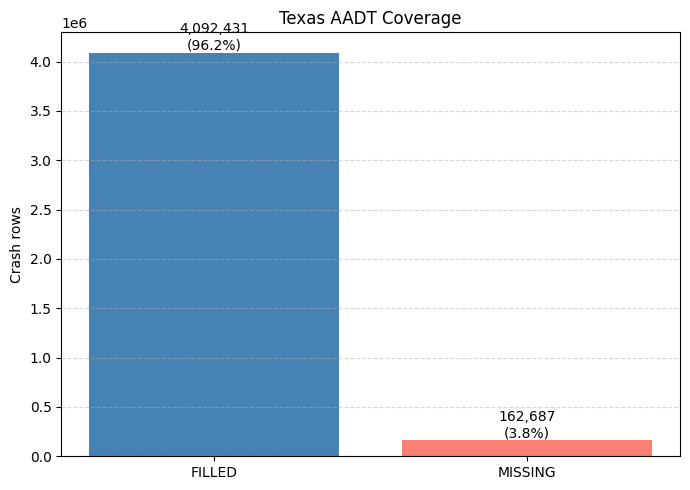

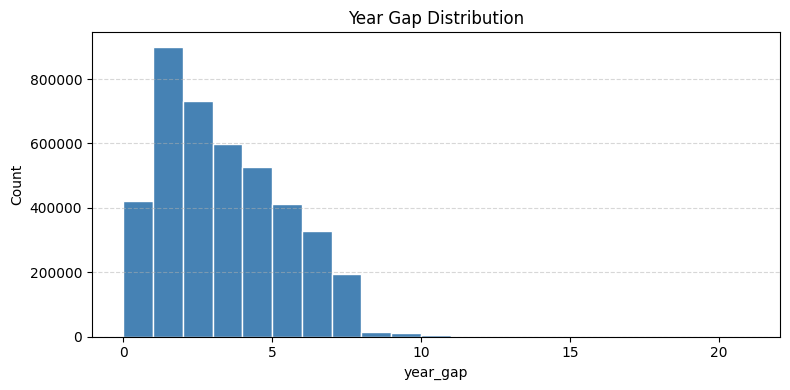

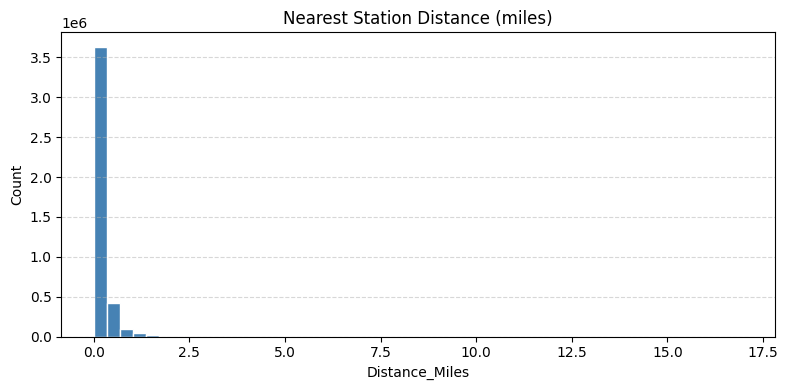

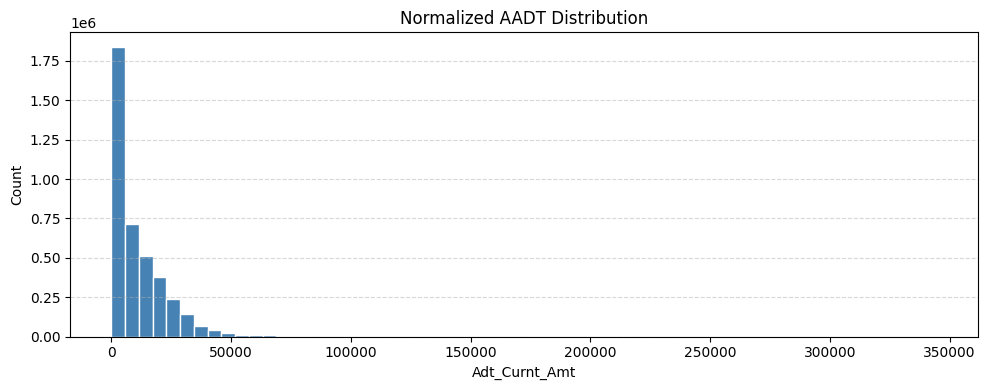

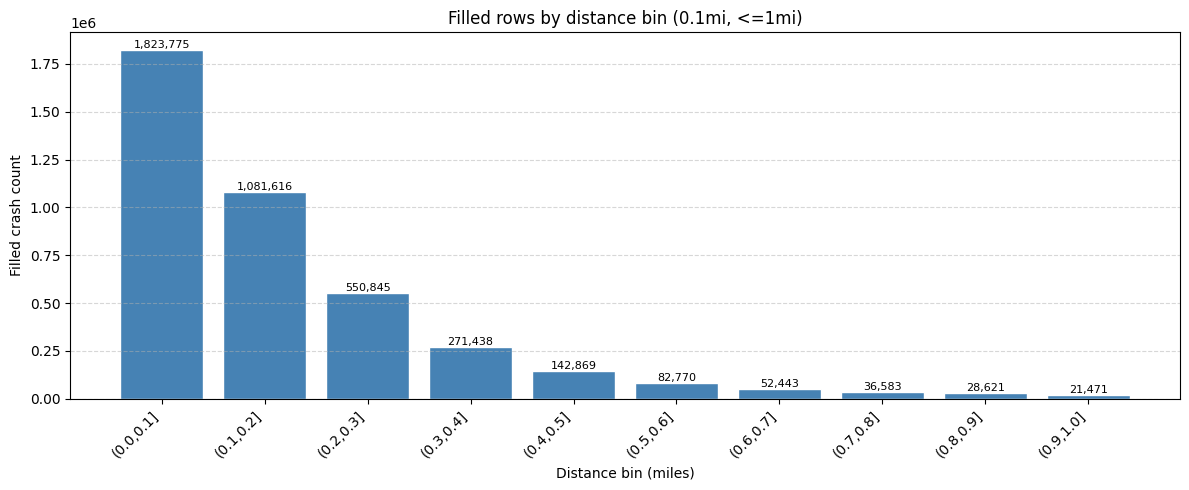

In [12]:
if df_all.height:
    filled  = df_all.filter(pl.col('Adt_Curnt_Amt').is_not_null()).height
    missing = df_all.height - filled
    total   = df_all.height

    # Plot 1: filled vs missing
    plt.figure(figsize=(7, 5))
    bars = plt.bar(['FILLED', 'MISSING'], [filled, missing], color=['steelblue', 'salmon'])
    plt.title('Texas AADT Coverage')
    plt.ylabel('Crash rows')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    for b in bars:
        v = int(b.get_height())
        pct = v / total * 100
        plt.text(b.get_x() + b.get_width() / 2, v, f'{v:,}\n({pct:.1f}%)', ha='center', va='bottom')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'plot1_filled_vs_missing.png'), dpi=150)
    plt.show()

    # Plot 2: year_gap histogram
    yg = df_all.filter(pl.col('year_gap').is_not_null())['year_gap'].to_numpy()
    plt.figure(figsize=(8, 4))
    plt.hist(yg, bins=range(0, int(yg.max()) + 2), color='steelblue', edgecolor='white')
    plt.title('Year Gap Distribution')
    plt.xlabel('year_gap')
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'plot2_year_gap.png'), dpi=150)
    plt.show()

    # Plot 3: distance histogram
    dist = df_all.filter(pl.col('Distance_Miles').is_not_null())['Distance_Miles'].to_numpy()
    plt.figure(figsize=(8, 4))
    plt.hist(dist, bins=50, color='steelblue', edgecolor='white')
    plt.title('Nearest Station Distance (miles)')
    plt.xlabel('Distance_Miles')
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'plot3_distance_hist.png'), dpi=150)
    plt.show()

    # Plot 4: AADT distribution
    aadt = df_all.filter(pl.col('Adt_Curnt_Amt').is_not_null())['Adt_Curnt_Amt'].to_numpy()
    plt.figure(figsize=(10, 4))
    plt.hist(aadt, bins=60, color='steelblue', edgecolor='white')
    plt.title('Normalized AADT Distribution')
    plt.xlabel('Adt_Curnt_Amt')
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'plot4_aadt_dist.png'), dpi=150)
    plt.show()

    # Plot 5: distance bin chart (0.1 mile bins, within 1 mile)
    df_1mi = df_all.filter(
        pl.col('Adt_Curnt_Amt').is_not_null()
        & (pl.col('Distance_Miles') <= 1.0)
        & (pl.col('Distance_Miles') >= 0.0)
    )
    bin_edges = np.round(np.arange(0.0, 1.0 + 0.1, 0.1), 2)
    dist_1mi = df_1mi['Distance_Miles'].to_numpy()
    counts, _ = np.histogram(dist_1mi, bins=bin_edges)
    labels = [f'({bin_edges[i]:.1f},{bin_edges[i+1]:.1f}]' for i in range(len(bin_edges) - 1)]
    plt.figure(figsize=(12, 5))
    bars = plt.bar(labels, counts, color='steelblue', edgecolor='white')
    plt.title('Filled rows by distance bin (0.1mi, <=1mi)')
    plt.xlabel('Distance bin (miles)')
    plt.ylabel('Filled crash count')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xticks(rotation=45, ha='right')
    for b in bars:
        v = int(b.get_height())
        plt.text(b.get_x() + b.get_width() / 2, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'plot5_distance_bins.png'), dpi=150)
    plt.show()


Required output column check, same as the pandas notebook.


In [13]:
required_cols = [
    'Crash_ID', 'Latitude', 'Longitude', 'ZIP_Code',
    'Adt_Curnt_Amt', 'Distance_Miles', 'Station_Year',
    'year_gap', 'aadt_match_type', 'VMT_Multiplier',
]

for df in all_outputs:
    yr = df['Crash_Year'][0]
    cols = df.columns
    missing = [c for c in required_cols if c not in cols]
    status = 'OK' if not missing else f'MISSING {missing}'
    print(f'{yr}: {status}  ({df.height:,} rows, {len(cols)} cols)')


2016: OK  (497,189 rows, 92 cols)
2017: OK  (484,825 rows, 92 cols)
2018: OK  (490,927 rows, 92 cols)
2019: OK  (504,885 rows, 92 cols)
2020: OK  (423,987 rows, 92 cols)
2021: OK  (491,698 rows, 92 cols)
2022: OK  (496,021 rows, 92 cols)
2023: OK  (377,107 rows, 92 cols)
2024: OK  (488,479 rows, 92 cols)


Timings summary.


In [14]:
if timings:
    tdf = pl.DataFrame(timings, schema=['year', 'rows', 'seconds'], orient='row')
    tdf = tdf.with_columns((pl.col('rows') / pl.col('seconds')).round(0).alias('rows_per_sec'))
    print(tdf)
    total = sum(t for _, _, t in timings)
    print(f'Total wall time: {total:.1f}s')


shape: (9, 4)
┌──────┬────────┬───────────┬──────────────┐
│ year ┆ rows   ┆ seconds   ┆ rows_per_sec │
│ ---  ┆ ---    ┆ ---       ┆ ---          │
│ i64  ┆ i64    ┆ f64       ┆ f64          │
╞══════╪════════╪═══════════╪══════════════╡
│ 2016 ┆ 497189 ┆ 59.517243 ┆ 8354.0       │
│ 2017 ┆ 484825 ┆ 48.954641 ┆ 9904.0       │
│ 2018 ┆ 490927 ┆ 56.141022 ┆ 8745.0       │
│ 2019 ┆ 504885 ┆ 50.620727 ┆ 9974.0       │
│ 2020 ┆ 423987 ┆ 46.665094 ┆ 9086.0       │
│ 2021 ┆ 491698 ┆ 51.075711 ┆ 9627.0       │
│ 2022 ┆ 496021 ┆ 55.267565 ┆ 8975.0       │
│ 2023 ┆ 377107 ┆ 41.357515 ┆ 9118.0       │
│ 2024 ┆ 488479 ┆ 59.834606 ┆ 8164.0       │
└──────┴────────┴───────────┴──────────────┘
Total wall time: 469.4s
